# Modus operandi:
**Here I am going to detect the spam and ham messege detection using the Natural Language Processing + different types of Machine learning
classification algorithms. From several ML algorithms the best algorithm will be choosen and deployed to web application. In the mean time,
our main aim to see the good precision that will help us to detect the real spam not the ham messeges unnecessarily.** 

# Now importing the necessary libraries:

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Now loading the dataset

In [146]:
path = r"C:\Users\Public\My projects\notebook\Notebook\Spam & Ham\spam.csv"
data = pd.read_csv(path, encoding="latin-1")
df = data.copy()
print("The head of the dataset is:")
print(df.head(5))
print("*" * 50)
print("The tail of the dataset is:")
print(df.tail(5))
print("*" * 50)

The head of the dataset is:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
**************************************************
The tail of the dataset is:
        v1                                                 v2 Unnamed: 2  \
5567  spam  This is the 2nd time we have tried 2 contact u...        NaN   
5568   ham              Will Ì_ b going to esplanade fr home?        NaN   
5569   ham  Pity, * was in mood for that. So...any other s...        N

# Now dropping the unnecessary columns

In [147]:
df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1, inplace=True)
df.rename(columns={"v1": "label", "v2": "text"}, inplace=True)
df.columns

Index(['label', 'text'], dtype='object')

In [148]:
df

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# Now lets do some visualization

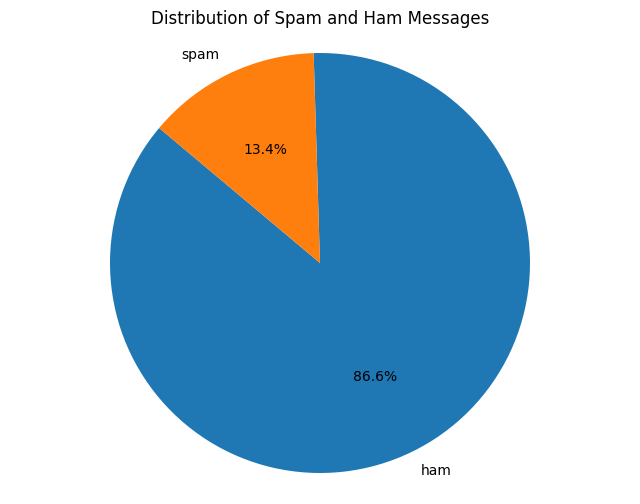

In [149]:
counts = df["label"].value_counts()
plt.figure(figsize=(8, 6))
plt.title("Distribution of Spam and Ham Messages")
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=140)
plt.axis("equal")
plt.show()

# Hmm quite imbalanced data which is normal because the spamming messege is quite rare in comparison of good messeges

# Now lets do some real cleaning of the data

In [150]:
!pip install nltk --upgrade nltk

In [151]:

import nltk
from nltk.corpus import wordnet
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.data.path.append(r'C:\Users\Public\My projects')


import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download("stopwords")
nltk.download("averaged_perceptron_tagger_eng")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
import string, re
from nltk import pos_tag


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\wwwal\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nl

In [152]:
stop = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    """Map POS tag to WordNet POS for lemmatization"""
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [153]:
def sentence_to_lemmatized_sentence(dataframe,column_name):
    corpus = []
    for documents in dataframe[column_name]:
        if isinstance(documents, list):
            documents = " ".join(documents)

        if isinstance(documents, str):
            documents = documents.lower()
            documents = re.sub(r"[^a-zA-Z]", " ", documents)
            sentences = sent_tokenize(documents)

            processed_sentences = []
            for sentence in sentences:
                words = word_tokenize(sentence)
                words = [word for word in words if word not in stop and word not in string.punctuation]
                tagged_words = pos_tag(words)
                words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_words]
                processed_sentences.append(" ".join(words))
            documents = " ".join(processed_sentences)

        corpus.append(documents)
    return corpus

In [154]:
final_corpus = sentence_to_lemmatized_sentence(df,"text")

In [155]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier,
                              AdaBoostClassifier,
                              ExtraTreesClassifier)
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Now come the train, test split and encoding and vectorization part

In [157]:
def model_evaluation(model, X_test, y_test):
    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"Accuracy for {model.__class__.__name__}: {acc}")
    print(f"Precision for {model.__class__.__name__}: {prec}")
    print(f"Recall for {model.__class__.__name__}: {rec}")
    print(f"F1 Score for {model.__class__.__name__}: {f1}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("**" * 50)
    
    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Confusion Matrix
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap="viridis",
        ax=axes[0]
    )
    axes[0].set_title(f"Confusion Matrix for {model.__class__.__name__}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    
    # ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    axes[1].plot(fpr, tpr, color="blue", label=f"ROC curve (AUC = {roc_auc:.2f})")
    axes[1].plot([0, 1], [0, 1], color="red", linestyle="--")
    axes[1].set_title(f"ROC Curve for {model.__class__.__name__}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

In [158]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0),
    "XGBoost": XGBClassifier(),
    "LightGBM": LGBMClassifier(),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}

# Now come the train, test split and encoding and vectorization part

In [159]:
X = pd.DataFrame(final_corpus, columns=["text"])
y = df["label"].map({"ham": 0, "spam": 1})
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [160]:
type(X_train), type(y_train), type(X_test), type(y_test)

(pandas.core.frame.DataFrame,
 pandas.core.series.Series,
 pandas.core.frame.DataFrame,
 pandas.core.series.Series)

In [161]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((3900, 1), (3900,), (1672, 1), (1672,))

# over all the sanity checks ensuring the data is not lost or deprecated 

In [162]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train["text"])
X_test_tfidf = vectorizer.transform(X_test["text"])

In [163]:
vectorizer.get_feature_names_out()

array(['able', 'abt', 'ac', 'account', 'account statement', 'actually',
       'add', 'address', 'aft', 'afternoon', 'age', 'ago', 'ah', 'aight',
       'al', 'alex', 'almost', 'alone', 'already', 'alright', 'also',
       'always', 'amp', 'angry', 'another', 'answer', 'anyone',
       'anything', 'anything lor', 'anyway', 'apply', 'appreciate', 'ard',
       'area', 'around', 'as', 'asap', 'ask', 'askd', 'attempt',
       'attempt contact', 'auction', 'available', 'await',
       'await collection', 'award', 'away', 'awesome', 'babe', 'baby',
       'back', 'bad', 'balance', 'bank', 'bath', 'bathe', 'beautiful',
       'bed', 'believe', 'best', 'bid', 'big', 'bill', 'birthday', 'bit',
       'blue', 'bonus', 'book', 'bore', 'bother', 'bout', 'box', 'boy',
       'boytoy', 'break', 'bring', 'brother', 'bslvyl', 'bt',
       'bt national', 'bus', 'busy', 'buy', 'call', 'call claim',
       'call customer', 'call identifier', 'call land', 'call landline',
       'call later', 'call mobil

# Now lets train ml algorithm

Accuracy for LogisticRegression: 0.9742822966507177
Precision for LogisticRegression: 0.983957219251337
Recall for LogisticRegression: 0.8214285714285714
F1 Score for LogisticRegression: 0.8953771289537712

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      1448
           1       0.98      0.82      0.90       224

    accuracy                           0.97      1672
   macro avg       0.98      0.91      0.94      1672
weighted avg       0.97      0.97      0.97      1672

****************************************************************************************************


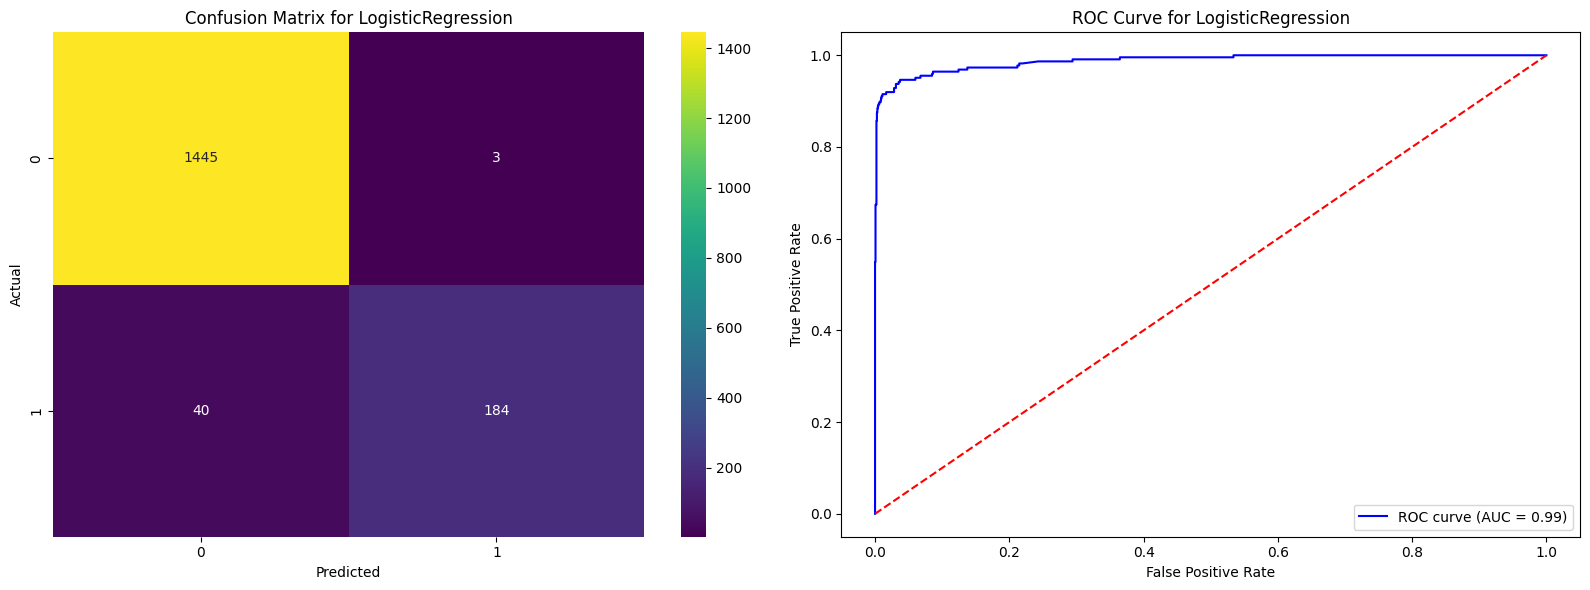

Accuracy for SVC: 0.9832535885167464
Precision for SVC: 1.0
Recall for SVC: 0.875
F1 Score for SVC: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       1.00      0.88      0.93       224

    accuracy                           0.98      1672
   macro avg       0.99      0.94      0.96      1672
weighted avg       0.98      0.98      0.98      1672

****************************************************************************************************


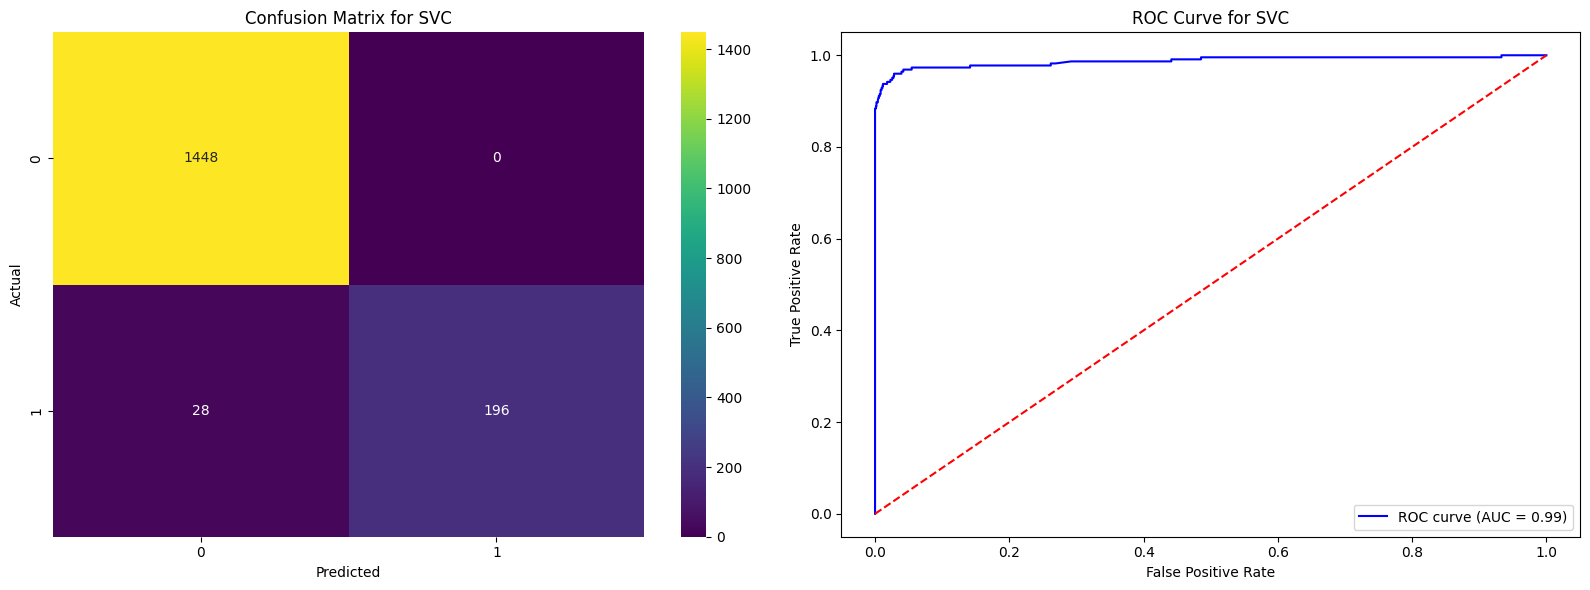

Accuracy for KNeighborsClassifier: 0.9252392344497608
Precision for KNeighborsClassifier: 1.0
Recall for KNeighborsClassifier: 0.4419642857142857
F1 Score for KNeighborsClassifier: 0.6130030959752323

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      1448
           1       1.00      0.44      0.61       224

    accuracy                           0.93      1672
   macro avg       0.96      0.72      0.79      1672
weighted avg       0.93      0.93      0.91      1672

****************************************************************************************************


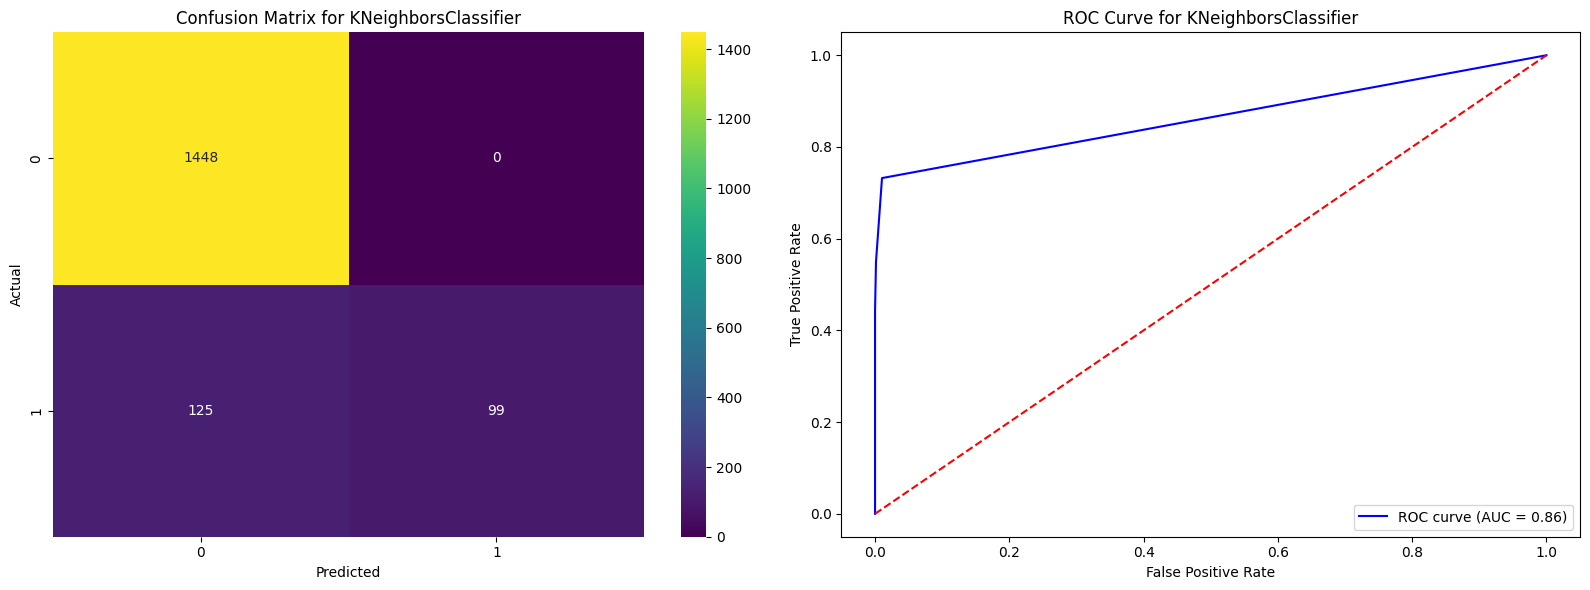

Accuracy for RandomForestClassifier: 0.9772727272727273
Precision for RandomForestClassifier: 0.965
Recall for RandomForestClassifier: 0.8616071428571429
F1 Score for RandomForestClassifier: 0.9103773584905661

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.96      0.86      0.91       224

    accuracy                           0.98      1672
   macro avg       0.97      0.93      0.95      1672
weighted avg       0.98      0.98      0.98      1672

****************************************************************************************************


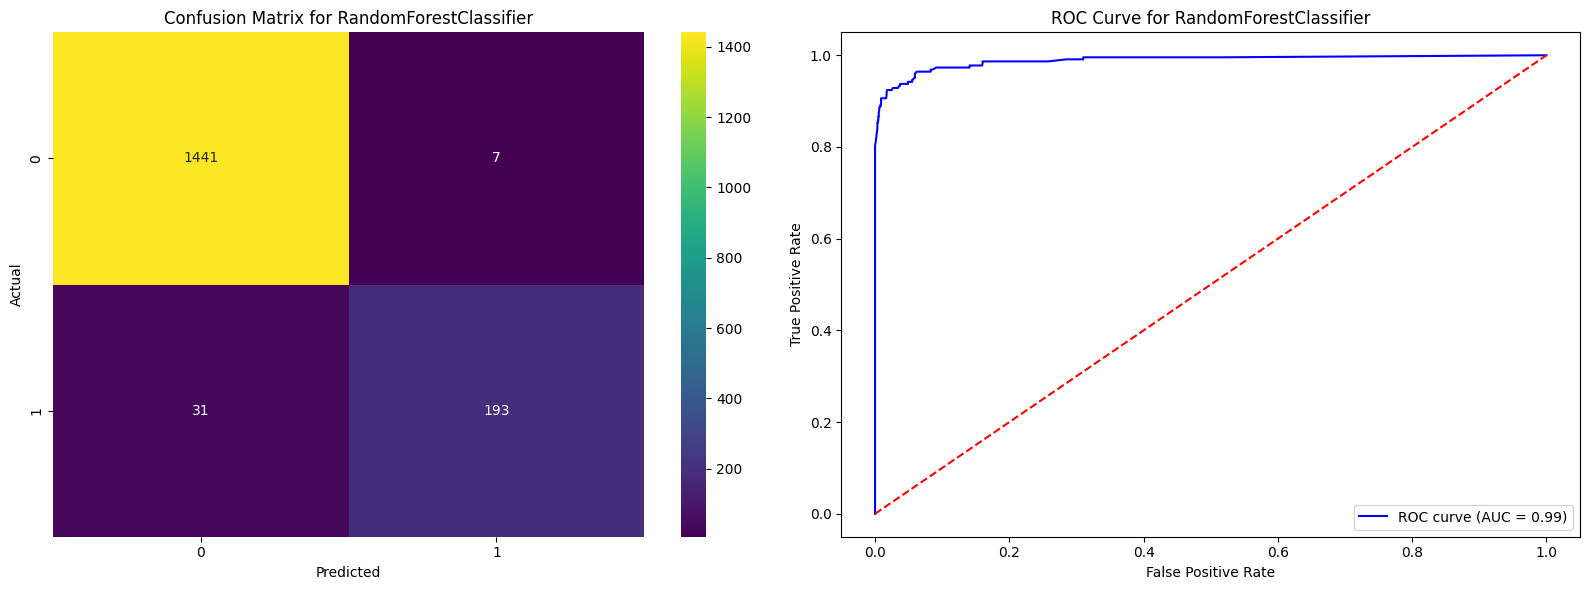

Accuracy for GradientBoostingClassifier: 0.9706937799043063
Precision for GradientBoostingClassifier: 0.9679144385026738
Recall for GradientBoostingClassifier: 0.8080357142857143
F1 Score for GradientBoostingClassifier: 0.8807785888077859

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1448
           1       0.97      0.81      0.88       224

    accuracy                           0.97      1672
   macro avg       0.97      0.90      0.93      1672
weighted avg       0.97      0.97      0.97      1672

****************************************************************************************************


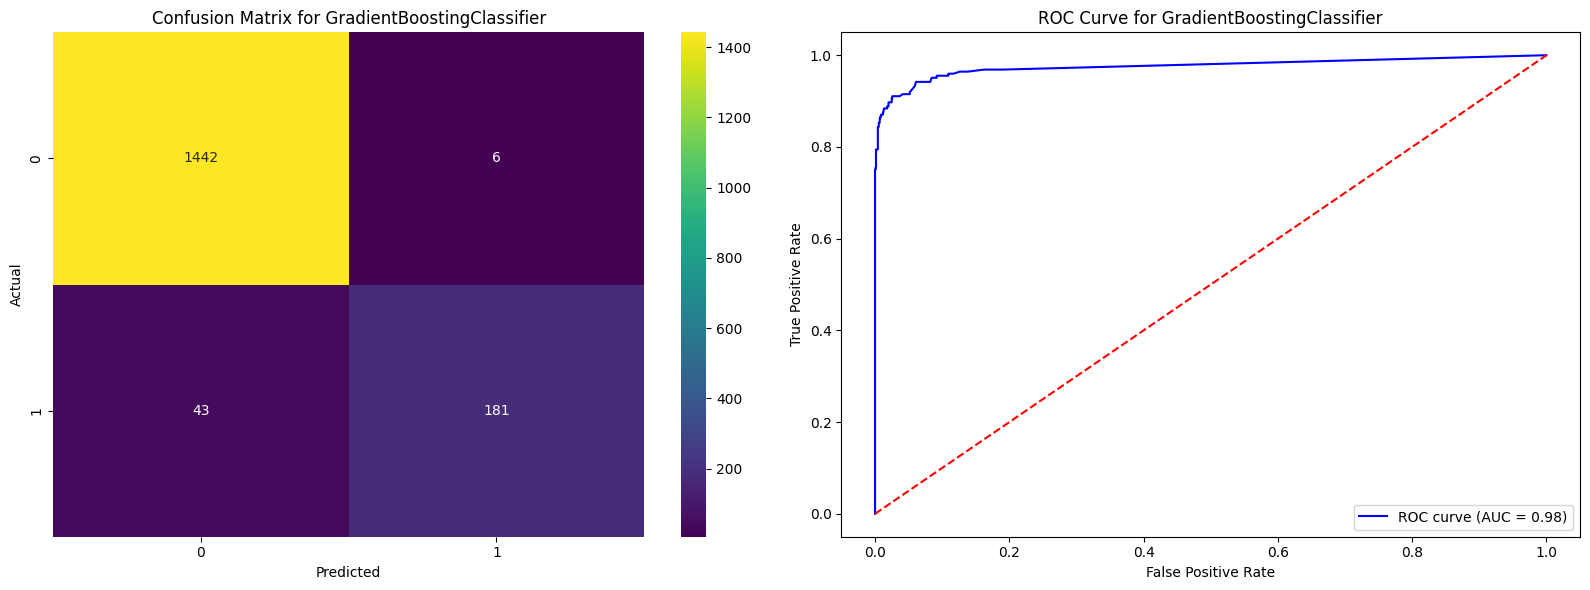

Accuracy for AdaBoostClassifier: 0.9712918660287081
Precision for AdaBoostClassifier: 0.9356435643564357
Recall for AdaBoostClassifier: 0.84375
F1 Score for AdaBoostClassifier: 0.8873239436619719

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1448
           1       0.94      0.84      0.89       224

    accuracy                           0.97      1672
   macro avg       0.96      0.92      0.94      1672
weighted avg       0.97      0.97      0.97      1672

****************************************************************************************************


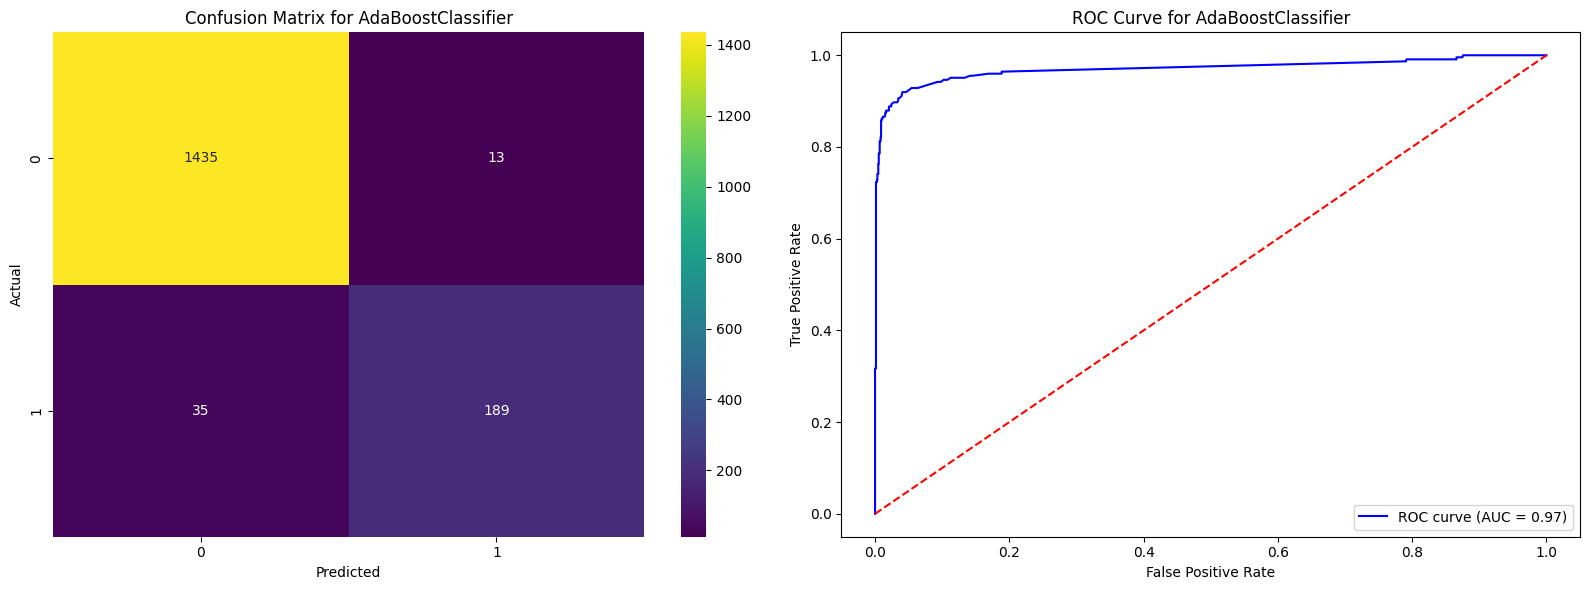

Accuracy for ExtraTreesClassifier: 0.9772727272727273
Precision for ExtraTreesClassifier: 0.9603960396039604
Recall for ExtraTreesClassifier: 0.8660714285714286
F1 Score for ExtraTreesClassifier: 0.9107981220657276

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1448
           1       0.96      0.87      0.91       224

    accuracy                           0.98      1672
   macro avg       0.97      0.93      0.95      1672
weighted avg       0.98      0.98      0.98      1672

****************************************************************************************************


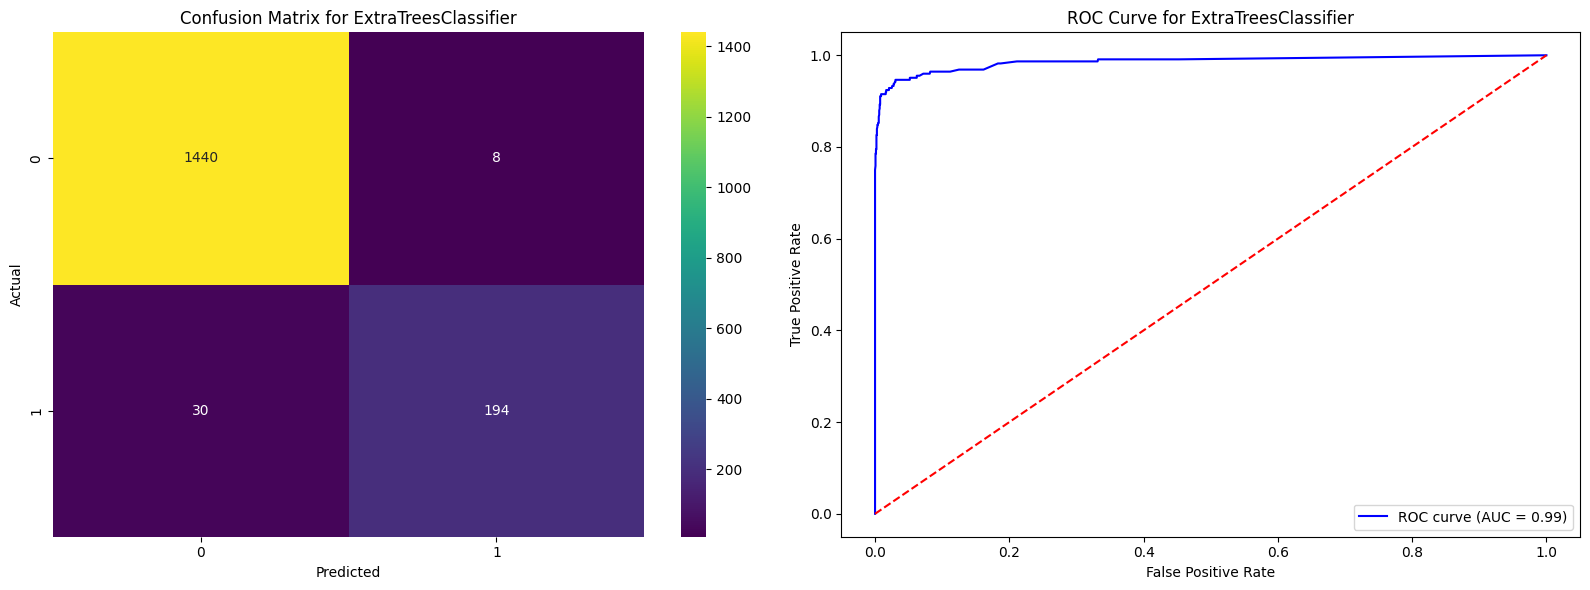

Accuracy for CatBoostClassifier: 0.9802631578947368
Precision for CatBoostClassifier: 0.9897435897435898
Recall for CatBoostClassifier: 0.8616071428571429
F1 Score for CatBoostClassifier: 0.9212410501193319

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.99      0.86      0.92       224

    accuracy                           0.98      1672
   macro avg       0.98      0.93      0.95      1672
weighted avg       0.98      0.98      0.98      1672

****************************************************************************************************


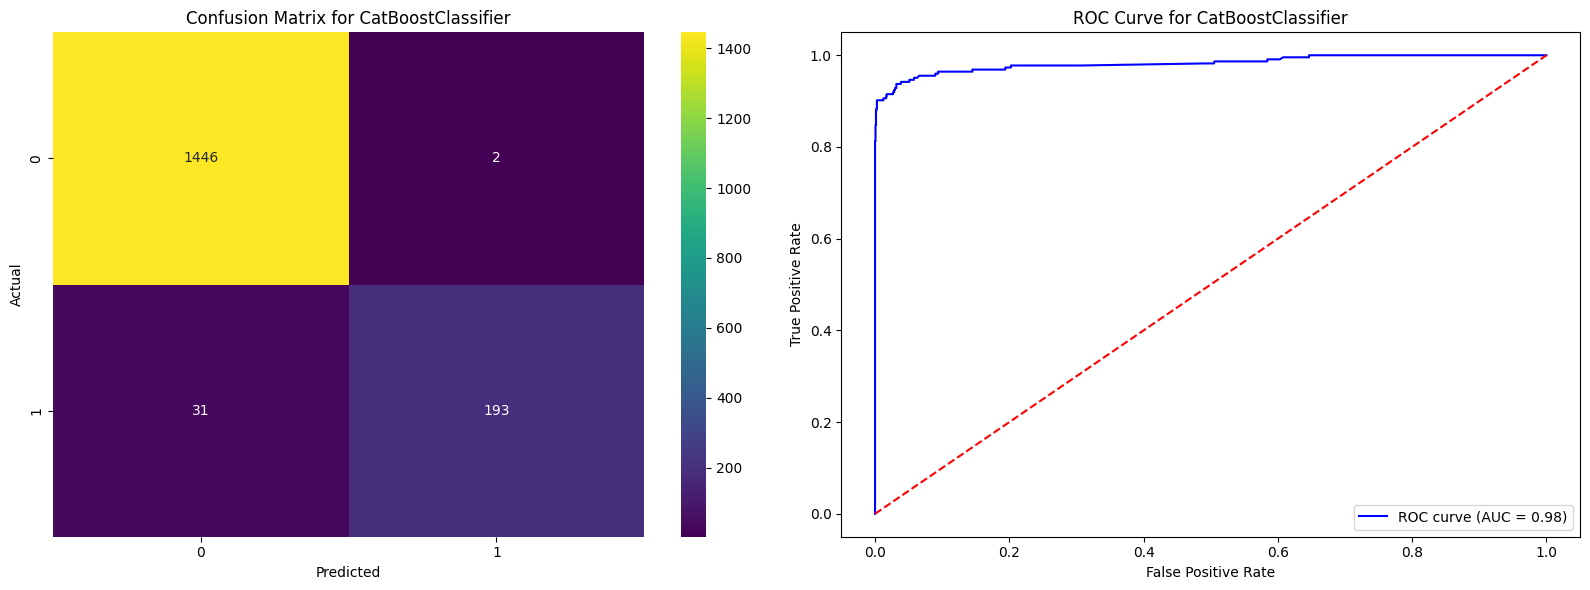

Accuracy for XGBClassifier: 0.9796650717703349
Precision for XGBClassifier: 0.9797979797979798
Recall for XGBClassifier: 0.8660714285714286
F1 Score for XGBClassifier: 0.919431279620853

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.98      0.87      0.92       224

    accuracy                           0.98      1672
   macro avg       0.98      0.93      0.95      1672
weighted avg       0.98      0.98      0.98      1672

****************************************************************************************************


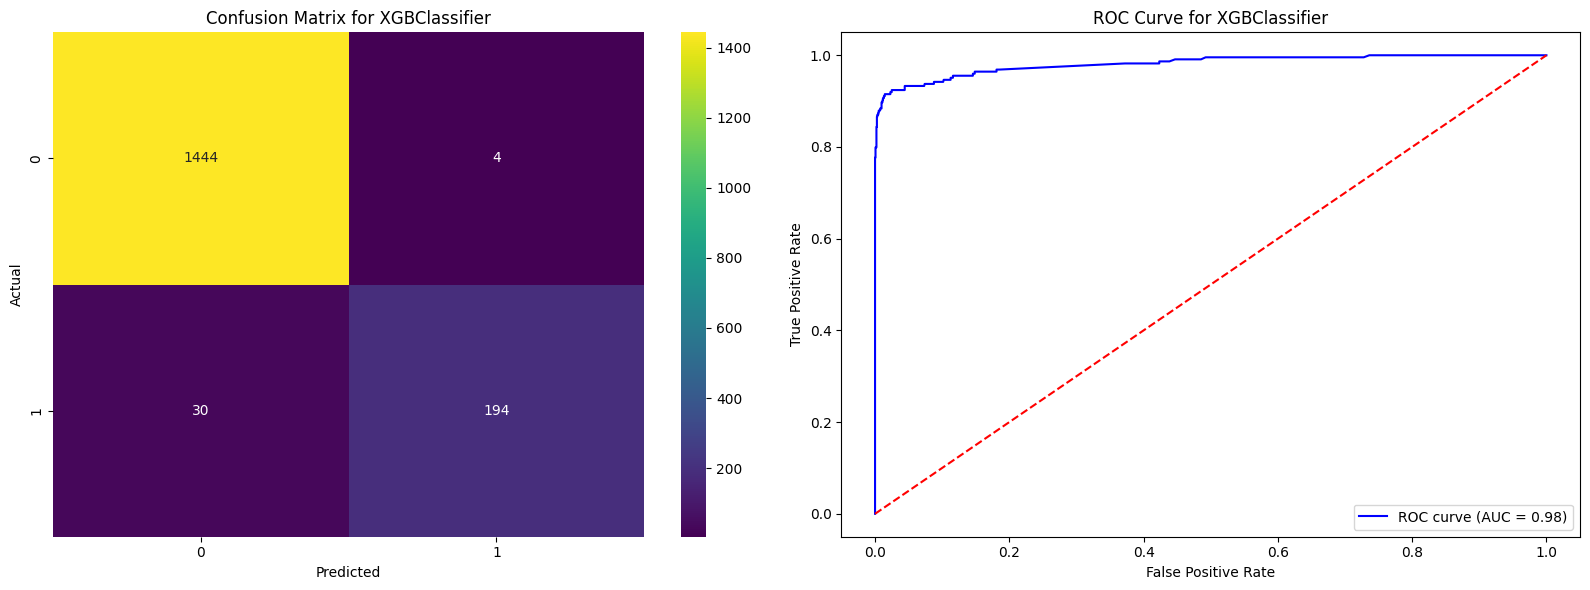

[LightGBM] [Info] Number of positive: 523, number of negative: 3377
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6076
[LightGBM] [Info] Number of data points in the train set: 3900, number of used features: 330
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134103 -> initscore=-1.865162
[LightGBM] [Info] Start training from score -1.865162
Accuracy for LGBMClassifier: 0.9760765550239234
Precision for LGBMClassifier: 0.9466019417475728
Recall for LGBMClassifier: 0.8705357142857143
F1 Score for LGBMClassifier: 0.9069767441860466

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1448
           1       0.95      0.87      0.91       224

    accuracy                           0.98      1672
   macro av

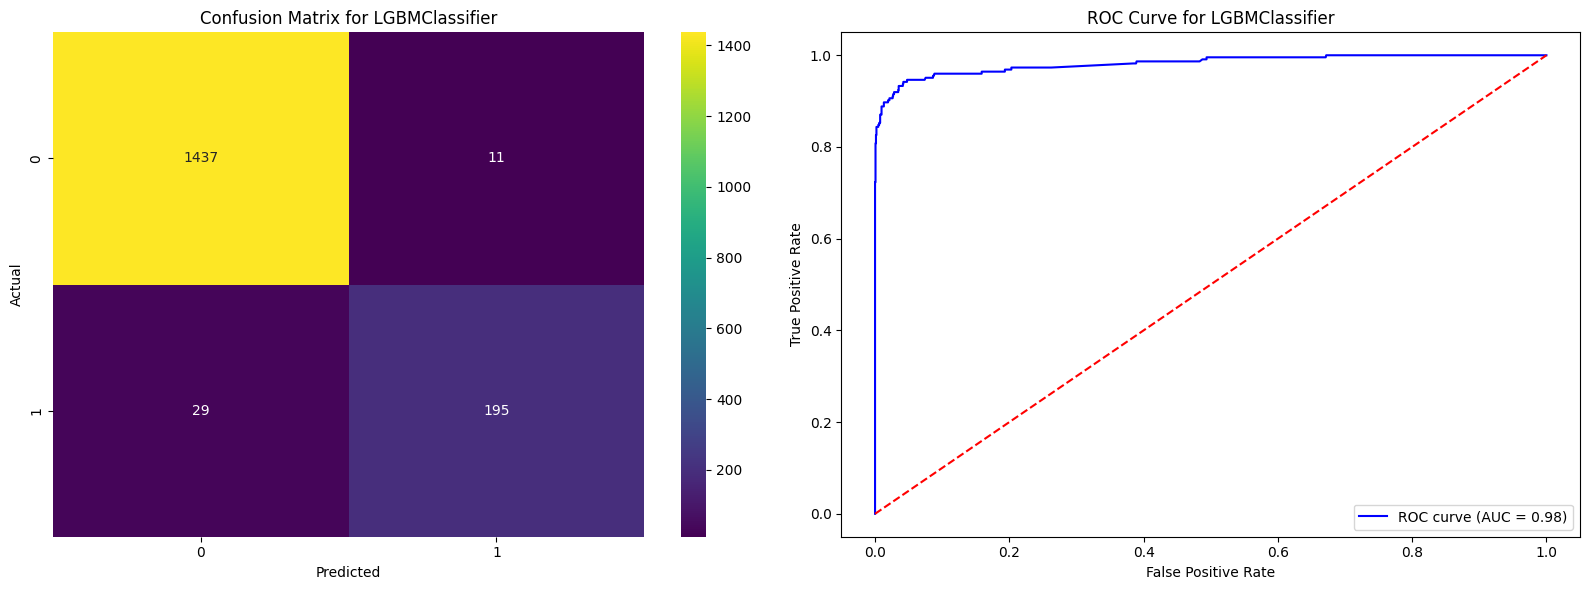

Accuracy for MultinomialNB: 0.9766746411483254
Precision for MultinomialNB: 0.9894179894179894
Recall for MultinomialNB: 0.8348214285714286
F1 Score for MultinomialNB: 0.9055690072639224

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1448
           1       0.99      0.83      0.91       224

    accuracy                           0.98      1672
   macro avg       0.98      0.92      0.95      1672
weighted avg       0.98      0.98      0.98      1672

****************************************************************************************************


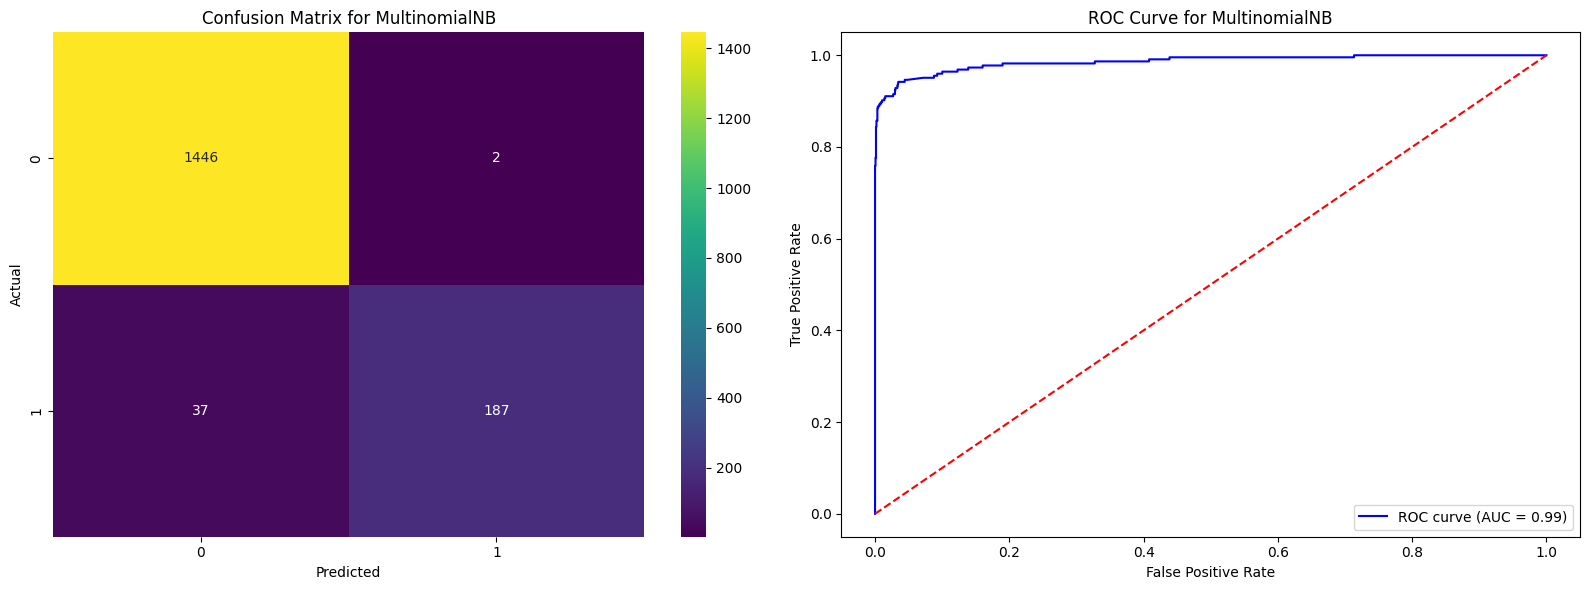

Accuracy for DecisionTreeClassifier: 0.9623205741626795
Precision for DecisionTreeClassifier: 0.8454935622317596
Recall for DecisionTreeClassifier: 0.8794642857142857
F1 Score for DecisionTreeClassifier: 0.8621444201312911

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1448
           1       0.85      0.88      0.86       224

    accuracy                           0.96      1672
   macro avg       0.91      0.93      0.92      1672
weighted avg       0.96      0.96      0.96      1672

****************************************************************************************************


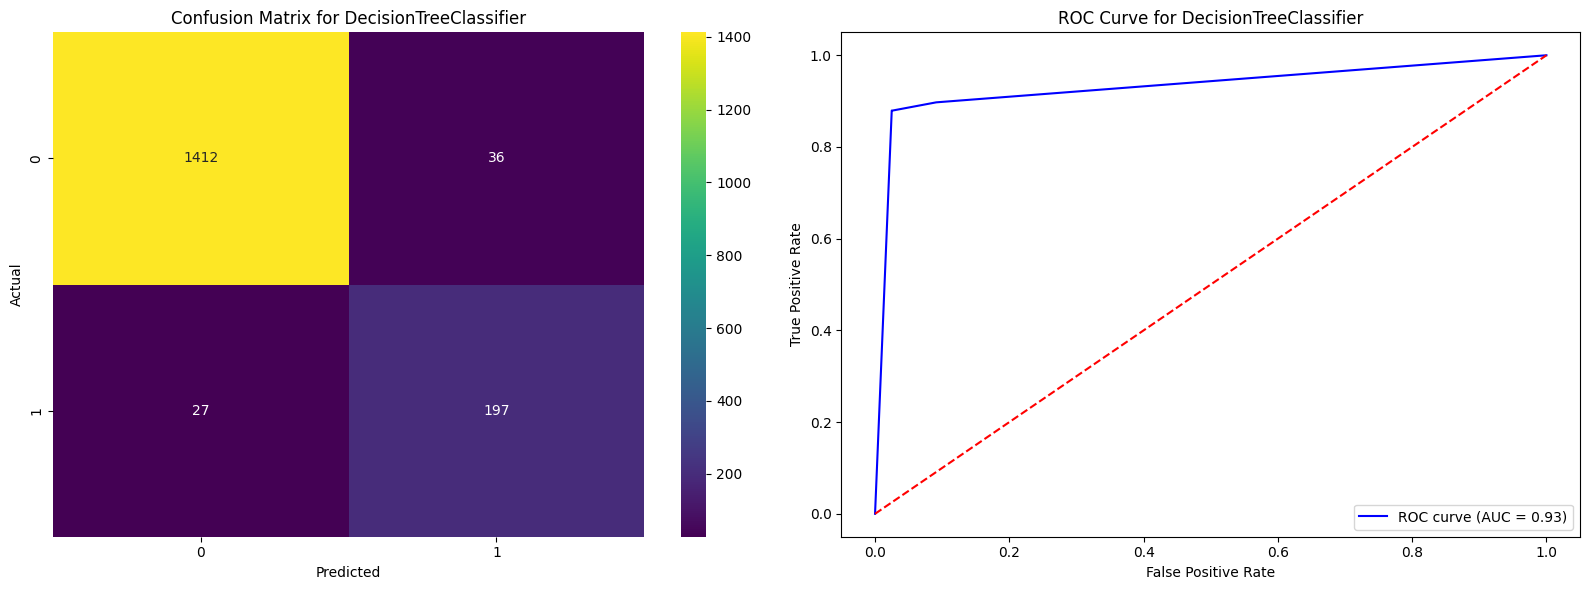

In [164]:
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    model_evaluation(model, X_test_tfidf, y_test)

In [165]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    # Some models may not have predict_proba
    try:
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    except Exception:
        roc_auc = None
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Precision (Spam)": precision,
        "Recall (Spam)": recall,
        "F1-score (Spam)": f1,
        "ROC AUC": roc_auc
    })

import pandas as pd
results_df = pd.DataFrame(results)
display(results_df.sort_values("F1-score (Spam)", ascending=False))

[LightGBM] [Info] Number of positive: 523, number of negative: 3377
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6076
[LightGBM] [Info] Number of data points in the train set: 3900, number of used features: 330
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.134103 -> initscore=-1.865162
[LightGBM] [Info] Start training from score -1.865162


,Model,Precision (Spam),Recall (Spam),F1-score (Spam),ROC AUC
1,Support Vector Machine,1.000000,0.875000,0.933333,0.987156
7,CatBoost,0.989744,0.861607,0.921241,0.982607
8,XGBoost,0.979798,0.866071,0.919431,0.981417
6,Extra Trees,0.970000,0.866071,0.915094,0.987867
3,Random Forest,0.974619,0.857143,0.912114,0.988181
9,LightGBM,0.946602,0.870536,0.906977,0.982218
10,Multinomial Naive Bayes,0.989418,0.834821,0.905569,0.985667
0,Logistic Regression,0.983957,0.821429,0.895377,0.987523
4,Gradient Boosting,0.973404,0.816964,0.888350,0.975634
5,AdaBoost,0.935644,0.843750,0.887324,0.970265


# Now lets pickling those tfidf and the trained support vector classifier ML model
---

The following code will save (pickle) both your trained TF-IDF vectorizer and the best SVC model for later use:

In [166]:
import pickle

# Save the trained TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

# Save the trained Support Vector Classifier model
best_svc = models["Support Vector Machine"]
best_svc.fit(X_train_tfidf, y_train)
with open("svc_model.pkl", "wb") as f:
    pickle.dump(best_svc, f)

print("TF-IDF vectorizer and SVC model have been saved.")

TF-IDF vectorizer and SVC model have been saved.


# Now lets load the model and do some prediction

In [173]:
with open("tfidf_vectorizer.pkl", "rb") as f:
    loaded_vectorizer = pickle.load(f)

with open("svc_model.pkl", "rb") as f:
    loaded_svc = pickle.load(f)

# Example prediction
sample_texts = [
    "Congratulations! You have won a free ticket. Call here to claim your prize.",
    "Hey, are we still meeting for lunch today?"
]

def preprocess_texts(texts):
    import pandas as pd
    df_new = pd.DataFrame(texts, columns=["text"])
    processed = sentence_to_lemmatized_sentence(df_new, "text")
    return processed

# Preprocess
processed_texts = preprocess_texts(sample_texts)

# Vectorize
sample_features = loaded_vectorizer.transform(processed_texts)

# Predict
predictions = loaded_svc.predict(sample_features)

for text, pred in zip(sample_texts, predictions):
    label = "Spam" if pred == 1 else "Ham"
    print(f"Text: {text}\nPrediction: {label}\n")

Text: Congratulations! You have won a free ticket. Call here to claim your prize.
Prediction: Spam

Text: Hey, are we still meeting for lunch today?
Prediction: Ham

